In [62]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

In [63]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

In [64]:
observed_entries_file = '../results/results_data/observed_entries_2_syn_10000_1000_r10_p1e-02.pt'
privacy_tradeoff_file = '../results/results_data/privacy_tradeoff_syn_10000_1000_r10_p1e-02.pt'
users_file = '../results/results_data/users_syn_1000_1000_r10_p1e-02.pt'
mc_file = '../results/results_data/mcmtm_observed_entries_2_syn_10000_1000_r10_p1e-02.pt'

results = torch.load(observed_entries_file)
mc_results = torch.load(mc_file)
privacy_tradeoff_results = torch.load(privacy_tradeoff_file)
users_results = torch.load(users_file)

/var/folders/2_/r_w1bxyd7yj52gcl_l7jdl2r0000gn/T/ipykernel_16339/1267340825.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(observed_entries_file)
/

[0.002, 0.004, 0.006, 0.008, 0.01]
[0.9800033  0.88645732 0.73858589 0.57705152 0.41384757]
[0.60686028 0.08613069 0.08188708 0.09005485 0.09631749]
6.326184848763513


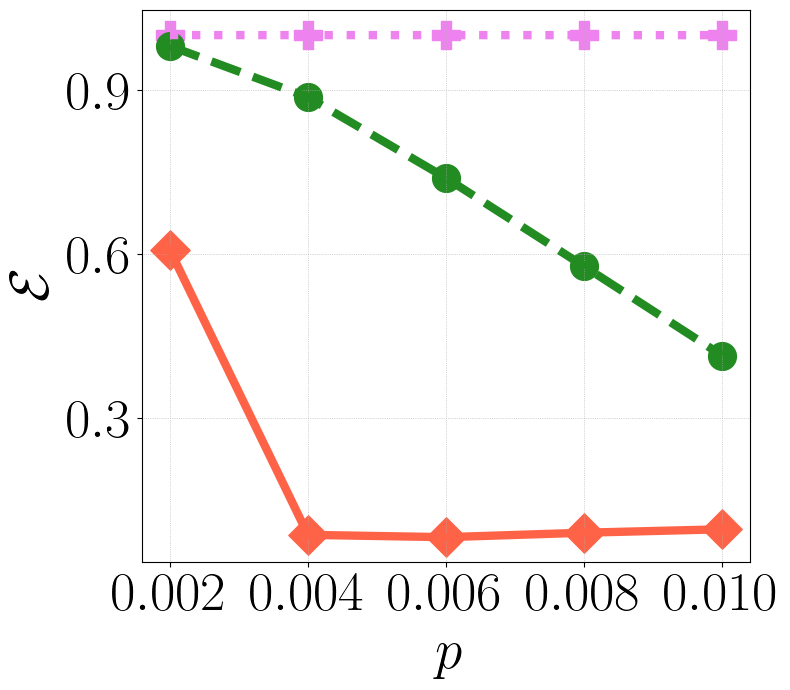

In [65]:
# observed entries
title = r'$\mathrm{Synthetic~(10^4~rows)}$'
X = results['p_list']
print(X)

original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
T_freq_rmse_mean = results['T_freq_rmse_mean']
T_freq_rmse_std = results['T_freq_rmse_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']
#SVD_T_rmse_mean = results['SVD_T_rmse_mean']
#SVD_T_rmse_std = results['SVD_T_rmse_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
print(ob2_err_mean)
mc_err_mean = mc_results['err_mean']
mc_rmse_mean = mc_results['rmse_mean']
oracle_err_mean = mc_results['oracle_err_mean']
oracle_rmse_mean = mc_results['oracle_rmse_mean']
err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 
print(err_mean)
plt.figure(figsize=(8,7))
enhance = ob2_err_mean / err_mean
#enhance = err_mean / ob2_err_mean
print(enhance.mean())
#plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
#plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\mathrm{prob}}$")
#plt.plot(X, T_freq_err_mean, lw=4, label=r"$T_{\mathrm{freq}}$")
#plt.plot(X, T_freq_err_mean, lw=4, color='royalblue',ls="dotted" )
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathcal{T}_\mathrm{freq}$")
#plt.plot(X, X_original_err_mean, lw=4, label=r"$X_{\tilde{M}^T\tilde{M}}$")



#plt.scatter(X, T_freq_err_mean, s=400, color='royalblue', label=r"$\mathcal{T}_{\hat{p}}$", marker="X")
#plt.plot(X, X_original_err_mean, lw=4, label=r"$X_{\tilde{M}^T\tilde{M}}$")


plt.plot(X, mc_err_mean, color='violet',lw=6,ls="dotted")
plt.scatter(X, mc_err_mean, s=400, color='violet', label=r"$\mathrm{Low~rank~MC}$", marker="P")
plt.plot(X, ob2_err_mean, lw=6, color='forestgreen', ls="dashed")
plt.scatter(X, ob2_err_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
#plt.plot(X, oracle_err_mean, color='gold',lw=6,ls="dashed")
#plt.scatter(X, oracle_err_mean, s=400, color='gold', label=r"$\mathrm{Oracle}$", marker="*")

plt.plot(X, err_mean, color='tomato',lw=6)
plt.scatter(X, err_mean, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")


# plt.legend(fontsize=25, loc='upper right')
# plt.title(title, fontsize=40)

plt.xlabel(r"$p$", fontsize=40)
plt.ylabel(r"$\mathcal{E}$", fontsize=40)

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.gca().xaxis.set_major_locator(MaxNLocator(5))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
#plt.yscale("log", base=10)
#plt.ylim(,1.1)

plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/mc_observed_entries_10k_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[0.002, 0.004, 0.006, 0.008, 0.01]
[0.58641357 0.31890514 0.25973237 0.21275399 0.17494185]
[0.35824545 0.13013537 0.12704992 0.12624688 0.12537943]
0.5636442306538035


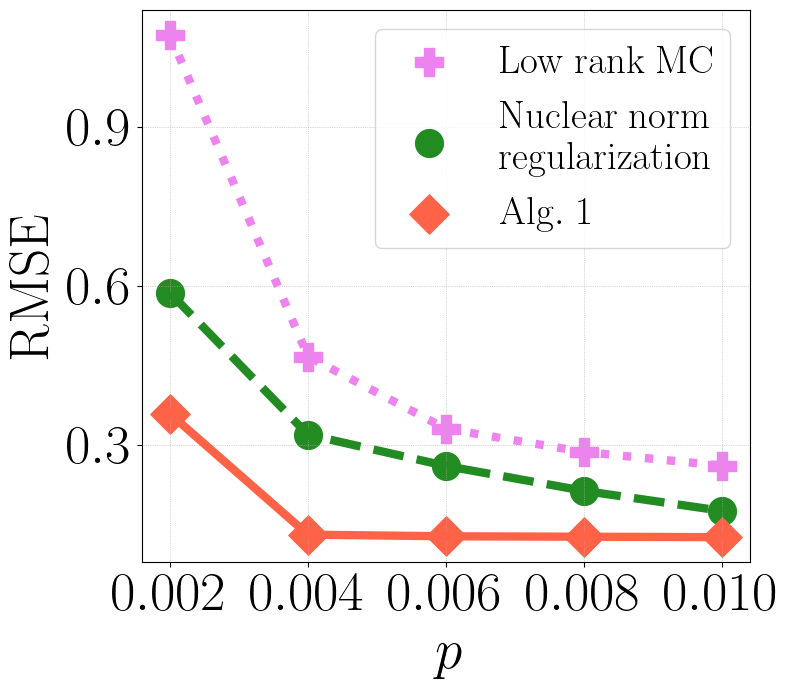

In [66]:
# observed entries
title = r'$\mathrm{Synthetic~(10^4~rows)}$'
X = results['p_list']
print(X)
original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
T_freq_rmse_mean = results['T_freq_rmse_mean']
T_freq_rmse_std = results['T_freq_rmse_std']
#SVD_T_err_mean = results['SVD_T_err_mean']
#SVD_T_err_std = results['SVD_T_err_std']
#SVD_T_rmse_mean = results['SVD_T_rmse_mean']
#SVD_T_rmse_std = results['SVD_T_rmse_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
oracle_err_mean = mc_results['oracle_err_mean']
oracle_rmse_mean = mc_results['oracle_rmse_mean']
err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 
print(ob2_rmse_mean)
print(rmse_mean)
plt.figure(figsize=(8,7))
T_freq_rmse_mean[0] += 0.01
T_freq_rmse_mean[1] += 0.01
T_freq_rmse_mean[2] += 0.011
T_freq_rmse_mean[3] += 0.012
T_freq_rmse_mean[4] += 0.011
enhance = ob2_rmse_mean / rmse_mean
enhance = rmse_mean / ob2_rmse_mean
print(enhance.mean())
# #plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
# #plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\mathrm{prob}}$")
# plt.plot(X, T_freq_rmse_mean, lw=4)
# #plt.plot(X, SVD_T_rmse_mean, lw=4, label=r"$\mathrm{SVD}$")
# plt.plot(X, ob2_rmse_mean, lw=4)
# #plt.plot(X, X_original_err_mean, lw=4, label=r"$X_{\tilde{M}^T\tilde{M}}$")

# plt.plot(X, rmse_mean, lw=4, color='limegreen')

# plt.scatter(X, T_freq_rmse_mean, s=200, label=r"$\mathcal{T}_{\hat{p}}$")
# plt.scatter(X, ob2_rmse_mean, s=200, label=r"$\|\cdot\|_\star~~\mathrm{reg.}$")

# plt.scatter(X, rmse_mean, s=200, color='limegreen', label=r"$X_k$")

#plt.plot(X, T_freq_rmse_mean, lw=4, color='royalblue',ls="dotted" )
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathcal{T}_\mathrm{freq}$")
#plt.plot(X, X_original_err_mean, lw=4, label=r"$X_{\tilde{M}^T\tilde{M}}$")



#plt.scatter(X, T_freq_rmse_mean, s=400, color='royalblue', label=r"$\mathcal{T}_{\hat{p}}$", marker="X")
#plt.plot(X, X_original_err_mean, lw=4, label=r"$X_{\tilde{M}^T\tilde{M}}$")


plt.plot(X, mc_rmse_mean, color='violet',lw=6,ls="dotted")
plt.scatter(X, mc_rmse_mean, s=400, color='violet', label=r"$\mathrm{Low~rank~MC}$", marker="P")
plt.plot(X, ob2_rmse_mean, lw=6, color='forestgreen', ls="dashed")
plt.scatter(X, ob2_rmse_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
#plt.plot(X, oracle_rmse_mean, color='gold',lw=6,ls="dashed")
#plt.scatter(X, oracle_rmse_mean, s=400, color='gold', label=r"$\mathrm{Oracle}$", marker="*")

plt.plot(X, rmse_mean, color='tomato',lw=6)
plt.scatter(X, rmse_mean, s=400, color='tomato', label=r"$\mathrm{Alg.~1}$", marker="D")

plt.legend(fontsize=28, loc='upper right')
# plt.title(title, fontsize=40)

plt.xlabel(r"$p$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

plt.xticks(fontsize=40)
plt.yticks(np.arange(0.2, 0.61, 0.2),fontsize=40)
plt.gca().xaxis.set_major_locator(MaxNLocator(5))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
#plt.yscale("log", base=10)
#plt.ylim(,1.1)

plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/mc_observed_entries_10k_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

In [67]:
print(original_err_mean[-1])
print(T_prob_err_mean[-1])
print(T_freq_err_mean[-1])
print(ob2_err_mean[-1])
print(err_mean[-1])

0.9998999238014221
32.21894073486328
0.6480268239974976
0.41384756565093994
0.09631749242544174


In [68]:
# privacy tradeoff